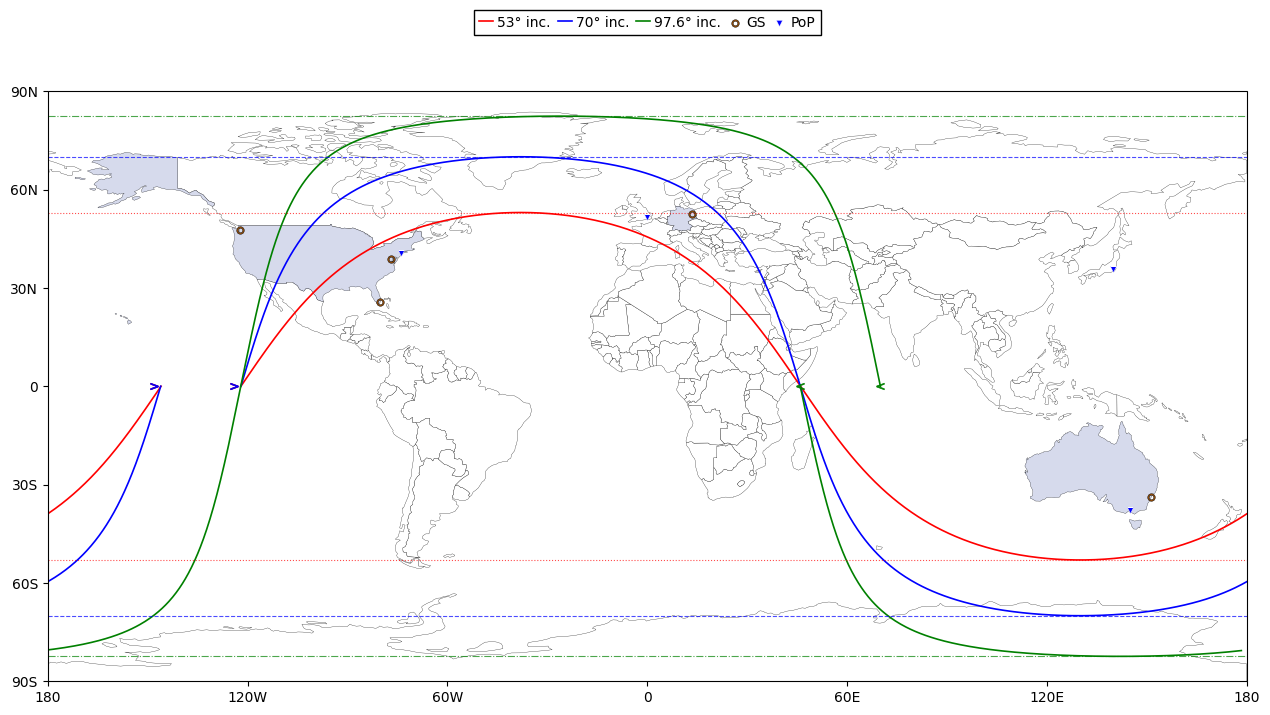

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas
from matplotlib import colors
import cartopy.crs as ccrs
from cartopy.io import shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# ============ 简单的轨道地面迹工具函数（替代 geospatial_plot_utils） ============
R_EARTH = 6378.137
MU = 398600.4418
SIDEREAL_DAY = 86164.0905
OMEGA_E = 2 * np.pi / SIDEREAL_DAY

def get_coords(inc_deg, raan_deg, alt_km, num_points, begin_time, portion=1):
    """
    返回一个轨道周期内的地面迹点列表：[(lat, lon), ...]
    这里简单用圆轨道 + 地球自转，忽略 begin_time 和 portion 的物理精确性，
    只是保证能画出和论文类似的轨道弧线。
    """
    inc = np.radians(inc_deg)
    raan = np.radians(raan_deg)

    a = R_EARTH + alt_km
    T = 2 * np.pi * np.sqrt(a**3 / MU)
    t = np.linspace(0, T, num_points)

    theta = 2 * np.pi * t / T  # 真近点角

    # 纬度
    sin_phi = np.sin(inc) * np.sin(theta)
    sin_phi = np.clip(sin_phi, -1.0, 1.0)
    phi = np.arcsin(sin_phi)
    lat = np.degrees(phi)

    # 赤经 + RAAN
    cos_i = np.cos(inc)
    alpha = np.arctan2(cos_i * np.sin(theta), np.cos(theta))
    alpha_unwrapped = np.unwrap(alpha) + raan

    # 格林尼治恒星时
    gst = OMEGA_E * t
    lam = np.degrees(alpha_unwrapped - gst)

    lon = ((lam + 180) % 360) - 180  # wrap 到 [-180,180]

    return list(zip(lat, lon)), None, None

def plot_period_groundtrack(coords, ax, color, label=None):
    """
    在给定 GeoAxes 上画一条地面迹，coords 为 [(lat, lon), ...]
    自动在经度跳变处断开。
    """
    lats = np.array([c[0] for c in coords])
    lons = np.array([c[1] for c in coords])

    segments = []
    cur_lon, cur_lat = [], []
    for i in range(len(lons)):
        if i > 0 and abs(lons[i] - lons[i-1]) > 180:
            if cur_lon:
                segments.append((np.array(cur_lon), np.array(cur_lat)))
            cur_lon, cur_lat = [], []
        cur_lon.append(lons[i])
        cur_lat.append(lats[i])
    if cur_lon:
        segments.append((np.array(cur_lon), np.array(cur_lat)))

    for lon_seg, lat_seg in segments:
        ax.plot(lon_seg, lat_seg,
                color=color, linewidth=1.2,
                transform=ccrs.PlateCarree(),
                label=label)
        # 只第一个 segment 用 label
        label = None

# ====================== 原始绘图逻辑（去掉外部数据） ============================
continents = ["AF", "AS", "EU", "NA", "OC", "SA"]
cols = ["#c1d5e2", "#ce9c7f", "#7598b6", "#6a7465", "#914c09", "#663979", "#fbe17b"]

# 使用 Cartopy 自带的 Natural Earth 数据
shpfilename = shpreader.natural_earth(
    resolution='110m', category='cultural', name='admin_0_countries'
)
world = geopandas.read_file(shpfilename)

# 自动选择国家名列
if "name" in world.columns:
    NAME_COL = "name"
elif "NAME" in world.columns:
    NAME_COL = "NAME"
elif "NAME_LONG" in world.columns:
    NAME_COL = "NAME_LONG"
else:
    print("Warning: 未找到国家名列，不高亮国家。")
    NAME_COL = None

fig, ax = plt.subplots(figsize=(12.8, 7.2), subplot_kw={'projection': ccrs.PlateCarree()})

cmap = colors.ListedColormap(cols[:-2])
world.plot(facecolor="white", edgecolor="black", ax=ax, linewidth=0.2)

# 高亮几个示例国家（代替外部 countries）
countries = ["United States of America", "Germany", "Australia"]

def plotCountryPatch(axes, country_name, fcolor):
    if NAME_COL is None:
        return
    nami = world[world[NAME_COL] == country_name]
    if nami.empty:
        return
    geom = nami.geometry
    axes.add_geometries(
        geom,
        crs=ccrs.PlateCarree(),
        facecolor=fcolor,
        edgecolor="none",
        alpha=0.2,
        zorder=2,
    )

for c in countries:
    plotCountryPatch(ax, c, "#364aa0")

begin_time = 1679408909

# 53° 轨道
coords, bc1, bc2 = get_coords(53, 238, 550, 1000, begin_time, portion=1)
plot_period_groundtrack(coords, ax, "red", label="53° inc.")
to_scatter = [coords[0], coords[-1]]
ax.scatter(
    [latlon[1] - 2 for latlon in to_scatter],
    [latlon[0] for latlon in to_scatter],
    marker='$>$', zorder=10, color="red", s=30.0, linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# 70° 轨道
coords, bc1, bc2 = get_coords(70, 238, 570, 1000, begin_time, portion=1)
plot_period_groundtrack(coords, ax, "blue", label="70° inc.")
to_scatter = [coords[0], coords[-1]]
ax.scatter(
    [latlon[1] - 2 for latlon in to_scatter],
    [latlon[0] for latlon in to_scatter],
    marker='$>$', zorder=10, color="blue", s=30.0, linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# 97.6° 轨道
coords, bc1, bc2 = get_coords(97.6, 70, 560, 1000, begin_time, portion=1)
plot_period_groundtrack(coords, ax, "green", label="97.6° inc.")
to_scatter = [coords[0], coords[-1]]
ax.scatter(
    [latlon[1] for latlon in to_scatter],
    [latlon[0] for latlon in to_scatter],
    marker='$<$', zorder=10, color="green", s=30.0, linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# 纬度覆盖线
def plot_extent(inclination, color="r", lw=1.4, alpha=0.7, lt="dotted"):
    if inclination > 90:
        inclination = 90 - (inclination % 90)
    ax.plot(
        [-180, 180], [inclination, inclination],
        linewidth=lw, color=color, linestyle=lt, alpha=alpha,
        transform=ccrs.PlateCarree()
    )
    ax.plot(
        [-180, 180], [-inclination, -inclination],
        linewidth=lw, color=color, linestyle=lt, alpha=alpha,
        transform=ccrs.PlateCarree()
    )

plot_extent(53, "r", lt="dotted", lw=0.8)
plot_extent(70, "b", lt="dashed", lw=0.8)
plot_extent(97.6, "g", lt="dashdot", lw=0.8)

# 简单构造几个 GS / PoP 点（替代 gateway_df / pop_df）
gateway_df = pd.DataFrame({
    "lat": [47.6, 25.8, -33.9, 38.9, 52.5],
    "long": [-122.3, -80.2, 151.2, -77.0, 13.4],
})
pop_df = pd.DataFrame({
    "lat": [40.7, 51.5, 35.7, -37.8],
    "long": [-74.0, -0.12, 139.8, 145.0],
})

def plot_gsdata(gsdata_df, ax, label, marker, color, size=10, lw=0.6):
    latitude, longitude = gsdata_df["lat"], gsdata_df["long"]
    ax.scatter(
        longitude, latitude,
        s=size,
        color=color,
        zorder=10,
        marker=marker,
        linewidths=lw,
        edgecolors="black" if marker == "$\\circ$" else "white",
        transform=ccrs.PlateCarree(),
        label=label,
    )

ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())


# ax.get_xaxis().set_ticks([])
# ax.get_yaxis().set_ticks([])
# ==== 增加经纬度刻度 ====
xticks = np.arange(-180, 181, 60)   # 经度刻度：-180, -120, ..., 180
yticks = np.arange(-90, 91, 30)     # 纬度刻度：-90, -60, ..., 90
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter(number_format='.0f', degree_symbol='')
lat_formatter = LatitudeFormatter(number_format='.0f', degree_symbol='')
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

plot_gsdata(gateway_df, ax, "GS", "$\\circ$", cols[4], 30, lw=0.3)
plot_gsdata(pop_df, ax, "PoP", "v", "blue", 20, lw=0.3)

ax.legend(
    loc='upper center', bbox_to_anchor=(0.50, 1.15),
    ncol=5, edgecolor="k", handlelength=1, labelspacing=0.06,
    columnspacing=0.5, fancybox=False, shadow=False,
    handletextpad=0.3, framealpha=1.0
).set_zorder(100)

plt.axis('tight')
plt.tight_layout()

result_path = "."  # 当前目录
plt.savefig(f"{result_path}/fig01_inclination_starlink_comparison_with_gws.pdf",dpi=300,
            bbox_inches="tight", pad_inches=0)


plt.savefig(f"{result_path}/fig01_inclination_starlink_comparison_with_gws.svg",
            bbox_inches="tight", pad_inches=0)
plt.show()
